In [5]:
%pip install -q -U google-genai
import IPython
IPython.Application.instance().kernel.do_shutdown(True)  # Restart kernel

{'status': 'ok', 'restart': True}

In [2]:
from google import genai
from google.genai import types
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage, Audio as IPAudio, Markdown

from google.colab import userdata

GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

In [3]:
# --- Sample images ---
!wget -q -O tree.png https://en.nikinclothing.com/blogs/nikin-blog/unsere-grunen-mitbewohner-7-interessante-fakten-uber-baume
!wget -q -O scones.jpg https://storage.googleapis.com/generativeai-downloads/images/scones.jpg
!wget -q -O cat.jpg https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/1200px-Cat03.jpg
!wget -q -O jetpack.png https://storage.googleapis.com/generativeai-downloads/data/jetpack.png
# --- Sample audio ---
!wget -q -O trees.wav https://www.gstatic.com/aistudio/starter-apps/multimodal-search/audio/trees.wav

print("Assets downloaded:")
!ls -lh tree.png scones.jpg cat.jpg trees.wav jatpack.png

Assets downloaded:
ls: cannot access 'jatpack.png': No such file or directory
-rw-r--r-- 1 root root 211K Apr 25  2025 cat.jpg
-rw-r--r-- 1 root root 386K Nov 27  2023 scones.jpg
-rw-r--r-- 1 root root 694K Mar 12 16:44 tree.png
-rw-r--r-- 1 root root 286K Mar  6 18:18 trees.wav


In [4]:
from google import genai
from google.genai import types
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage, Audio as IPAudio, Markdown

client = genai.Client(api_key=GEMINI_API_KEY)

MODEL_ID = "gemini-embedding-2-preview"
print(f"Using model: {MODEL_ID}")

Using model: gemini-embedding-2-preview


In [5]:


result = client.models.embed_content(
        model="gemini-embedding-001",
        contents="What is the meaning of life?"
)

[embedding_obj] = result.embeddings
embedding_length = len(embedding_obj.values)

print(f"Length of embedding: {embedding_length}")

Length of embedding: 3072


In [6]:
def embed_text(text: str) -> np.ndarray:
    """Encode a text string into an embedding vector.

    Simply pass the string directly to embed_content.
    """
    result = client.models.embed_content(
        model=MODEL_ID,
        contents=[text],
    )
    return np.array(result.embeddings[0].values)


def embed_image(image_path: str) -> np.ndarray:
    """Encode an image file (PNG or JPEG) into an embedding vector.

    Read the file as bytes and wrap it in types.Part.from_bytes
    with the appropriate MIME type.
    """
    # Determine MIME type from extension
    ext = image_path.lower().rsplit('.', 1)[-1]
    mime_map = {'png': 'image/png', 'jpg': 'image/jpeg', 'jpeg': 'image/jpeg'}
    mime_type = mime_map.get(ext, 'image/png')

    with open(image_path, 'rb') as f:
        image_bytes = f.read()

    result = client.models.embed_content(
        model=MODEL_ID,
        contents=[
            types.Part.from_bytes(data=image_bytes, mime_type=mime_type),
        ],
    )
    return np.array(result.embeddings[0].values)


def embed_audio(audio_path: str) -> np.ndarray:
    """Encode an audio file (WAV or MP3) into an embedding vector.

    Read the file as bytes and wrap it in types.Part.from_bytes
    with the appropriate MIME type. Max duration: 80 seconds.
    """
    ext = audio_path.lower().rsplit('.', 1)[-1]
    mime_map = {'wav': 'audio/wav', 'mp3': 'audio/mp3'}
    mime_type = mime_map.get(ext, 'audio/wav')

    with open(audio_path, 'rb') as f:
        audio_bytes = f.read()

    result = client.models.embed_content(
        model=MODEL_ID,
        contents=[
            types.Part.from_bytes(data=audio_bytes, mime_type=mime_type),
        ],
    )
    return np.array(result.embeddings[0].values)

def embed_video(video_path: str) -> np.ndarray:
    """Encode a video file (MP4, MOV, AVI, etc.) into an embedding vector.

    Read the file as bytes and wrap it in types.Part.from_bytes
    with the appropriate MIME type.
    """
    ext = video_path.lower().rsplit('.', 1)[-1]
    mime_map = {
        'mp4':  'video/mp4',
        'mov':  'video/mov',
        'avi':  'video/avi',
        'mkv':  'video/mkv',
        'webm': 'video/webm',
    }
    mime_type = mime_map.get(ext, 'video/mp4')

    with open(video_path, 'rb') as f:
        video_bytes = f.read()

    result = client.models.embed_content(
        model=MODEL_ID,
        contents=[
            types.Part.from_bytes(data=video_bytes, mime_type=mime_type),
        ],
    )
    return np.array(result.embeddings[0].values)

# Encode one example of each modality
text_emb = embed_text("A sketch of a jetpack backpack")
image_emb = embed_image("/content/tree-oak-landscape-view-53435.jpeg")
audio_emb = embed_audio("trees.wav")
video_emb = embed_video("/content/Trees free stock footage - stock footage - stock video - royalty free background video hd.mp4")
print(f"Text  embedding shape: {text_emb.shape}  (first 5 values: {text_emb[:5]})")
print(f"Image embedding shape: {image_emb.shape}  (first 5 values: {image_emb[:5]})")
print(f"Audio embedding shape: {audio_emb.shape}  (first 5 values: {audio_emb[:5]})")
print(f"\nAll modalities produce {text_emb.shape[0]}-dimensional vectors in the same space!")
print(f"Audio embedding shape: {video_emb.shape}  (first 5 values: {video_emb[:5]})")

Text  embedding shape: (3072,)  (first 5 values: [-0.05405017  0.02282848  0.00459767  0.0128538   0.03284248])
Image embedding shape: (3072,)  (first 5 values: [-0.0071451  -0.03719401  0.00731259  0.01884756  0.01352974])
Audio embedding shape: (3072,)  (first 5 values: [-0.01469159  0.02238123 -0.01320668  0.01185066  0.03557808])

All modalities produce 3072-dimensional vectors in the same space!
Audio embedding shape: (3072,)  (first 5 values: [-0.01918443 -0.0350613   0.00924603 -0.01093939  0.00312033])


In [7]:
# --- Define text descriptions ---
text_descriptions = [
    "A sketch of a jetpack backpack",
    "A person flying with a jetpack through the sky",
    "Freshly baked scones with jam and cream on a plate",
    "A cute ginger cat sitting and looking at the camera",
    "Trees and nature sounds in a peaceful forest",
    "A rocket launching into space",
]

# --- Define image files ---
image_files = ["jetpack.png", "scones.jpg", "cat.jpg"]
image_labels = ["jetpack.png", "scones.jpg", "cat.jpg"]

# --- Compute embeddings ---
print("Embedding texts...")
text_embeddings = np.array([embed_text(t) for t in text_descriptions])

print("Embedding images...")
image_embeddings = np.array([embed_image(f) for f in image_files])

print(f"\nText embeddings matrix:  {text_embeddings.shape}  (5 texts x 3072 dims)")
print(f"Image embeddings matrix: {image_embeddings.shape}  (3 images x 3072 dims)")

Embedding texts...
Embedding images...

Text embeddings matrix:  (6, 3072)  (5 texts x 3072 dims)
Image embeddings matrix: (3, 3072)  (3 images x 3072 dims)


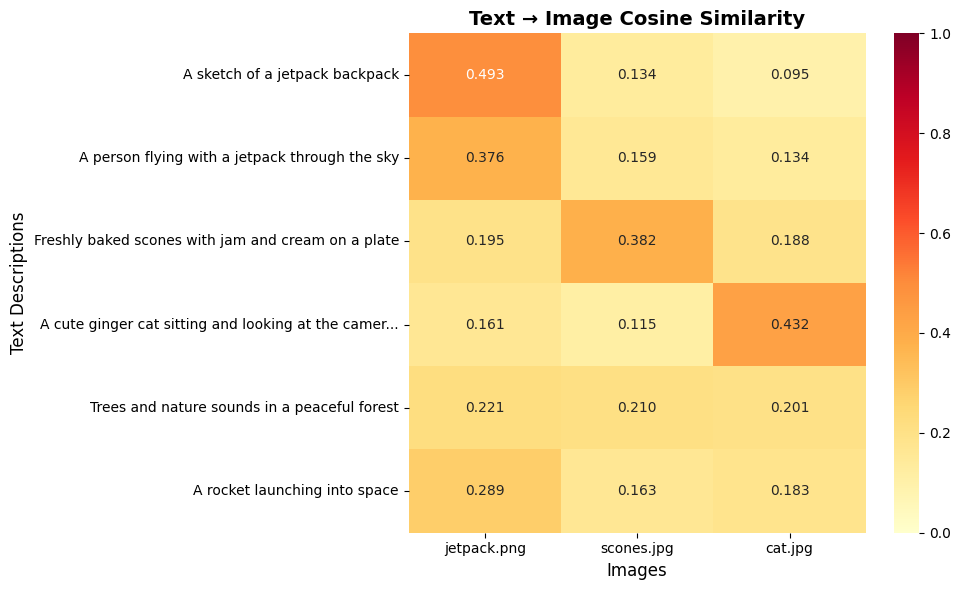


🎯 Best text match for each image:
  jetpack.png     → "A sketch of a jetpack backpack" (score: 0.493)
  scones.jpg      → "Freshly baked scones with jam and cream on a plate" (score: 0.382)
  cat.jpg         → "A cute ginger cat sitting and looking at the camera" (score: 0.432)


In [8]:
# Cosine similarity: (num_texts x num_images)
text_image_sim = cosine_similarity(text_embeddings, image_embeddings)

# Shorten labels for display
short_texts = [t[:50] + "..." if len(t) > 50 else t for t in text_descriptions]

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    text_image_sim,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    xticklabels=image_labels,
    yticklabels=short_texts,
    vmin=0, vmax=1,
)
ax.set_xlabel("Images", fontsize=12)
ax.set_ylabel("Text Descriptions", fontsize=12)
ax.set_title("Text → Image Cosine Similarity", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print best matches
print("\n\U0001f3af Best text match for each image:")
for j, img in enumerate(image_labels):
    best_idx = np.argmax(text_image_sim[:, j])
    print(f"  {img:15s} \u2192 \"{text_descriptions[best_idx]}\" (score: {text_image_sim[best_idx, j]:.3f})")

Embedding audio...


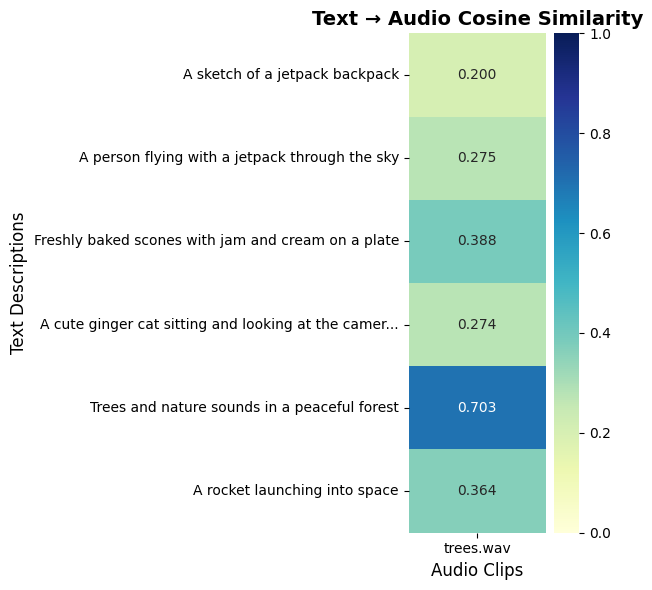


🎯 Best text match for trees.wav:
  "Trees and nature sounds in a peaceful forest" (score: 0.703)


In [9]:
# --- Embed audio ---
audio_files = ["trees.wav"]
audio_labels = ["trees.wav"]

print("Embedding audio...")
audio_embeddings = np.array([embed_audio(f) for f in audio_files])

# --- Text-to-Audio similarity ---
text_audio_sim = cosine_similarity(text_embeddings, audio_embeddings)

plt.figure(figsize=(6, 6))
ax = sns.heatmap(
    text_audio_sim,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=audio_labels,
    yticklabels=short_texts,
    vmin=0, vmax=1,
)
ax.set_xlabel("Audio Clips", fontsize=12)
ax.set_ylabel("Text Descriptions", fontsize=12)
ax.set_title("Text → Audio Cosine Similarity", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print best match
best_idx = np.argmax(text_audio_sim[:, 0])
print(f"\n\U0001f3af Best text match for trees.wav:")
print(f"  \"{text_descriptions[best_idx]}\" (score: {text_audio_sim[best_idx, 0]:.3f})")

Embedding audio...


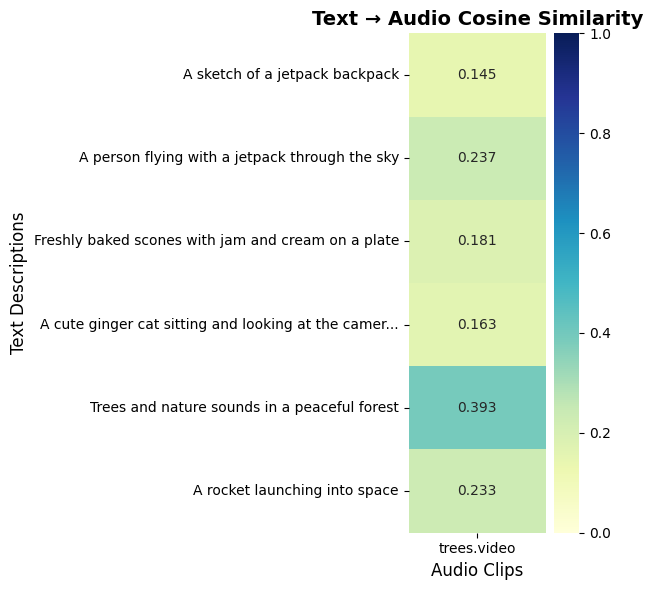


🎯 Best text match for trees.wav:
  "Trees and nature sounds in a peaceful forest" (score: 0.393)


In [10]:
# --- Embed audio ---
video_files = ["/content/Trees free stock footage - stock footage - stock video - royalty free background video hd.mp4"]
video_labels = ["trees.video"]

print("Embedding audio...")
video_embeddings = np.array([embed_video(f) for f in video_files])

# --- Text-to-Video similarity ---
text_video_sim = cosine_similarity(text_embeddings, video_embeddings)

plt.figure(figsize=(6, 6))
ax = sns.heatmap(
    text_video_sim,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=video_labels,
    yticklabels=short_texts,
    vmin=0, vmax=1,
)
ax.set_xlabel("Audio Clips", fontsize=12)
ax.set_ylabel("Text Descriptions", fontsize=12)
ax.set_title("Text → Audio Cosine Similarity", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print best match
best_idx = np.argmax(text_video_sim[:, 0])
print(f"\n\U0001f3af Best text match for trees.wav:")
print(f"  \"{text_descriptions[best_idx]}\" (score: {text_video_sim[best_idx, 0]:.3f})")

Embedding expanded text corpus (10 entries)...



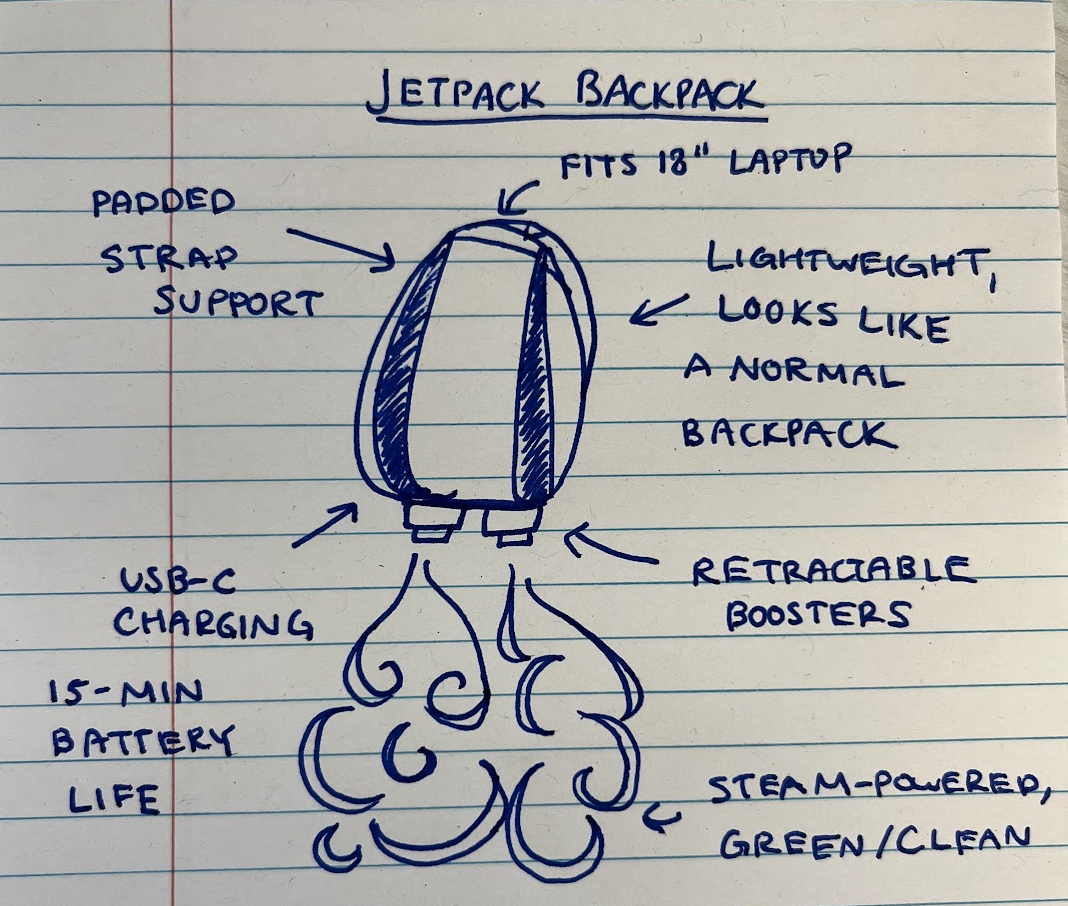

🔍 Top 3 text matches for jetpack.png:
  1. "A sketch of a jetpack backpack" (score: 0.493)
  2. "A person flying with a jetpack through the sky" (score: 0.376)
  3. "A rocket launching into space" (score: 0.289)



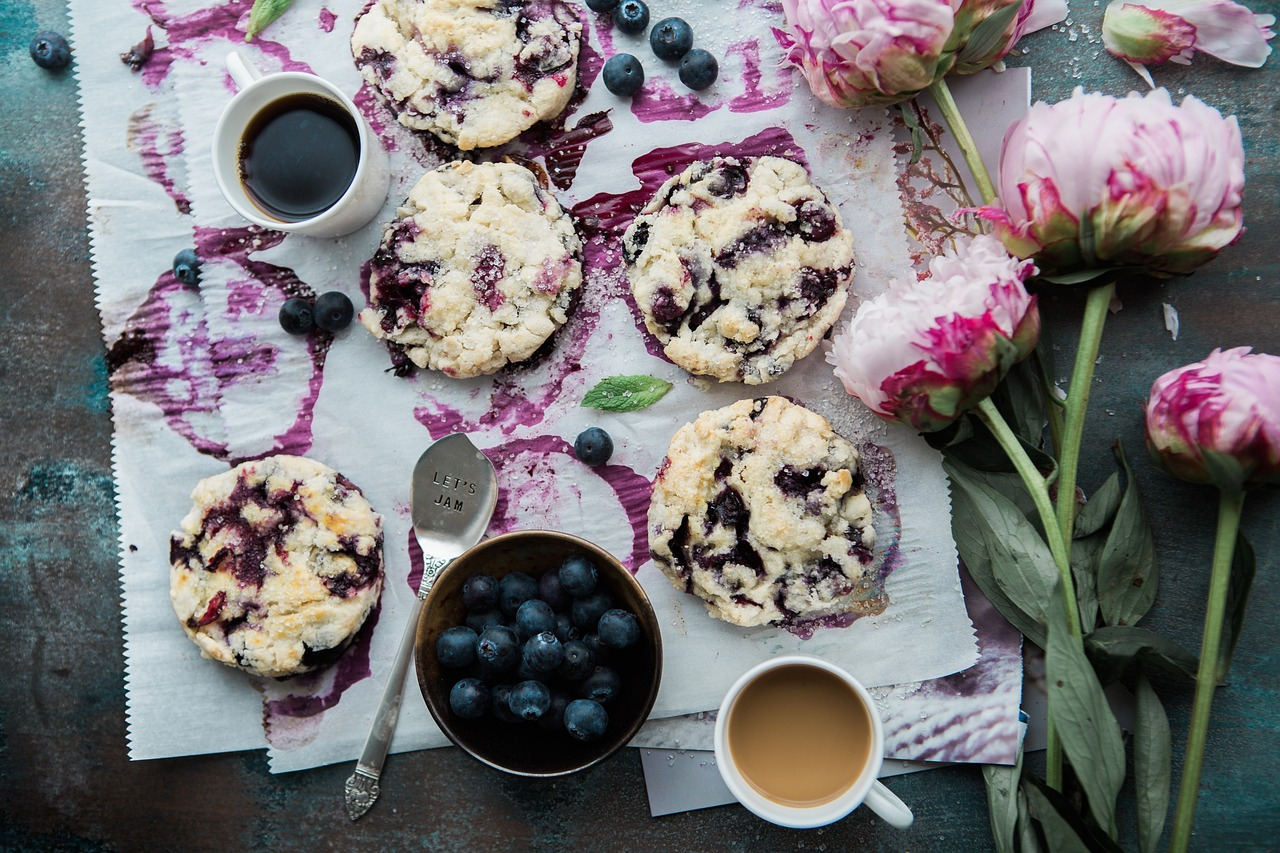

🔍 Top 3 text matches for scones.jpg:
  1. "Freshly baked scones with jam and cream on a plate" (score: 0.382)
  2. "A cozy fireplace with a cup of hot chocolate" (score: 0.217)
  3. "Trees and nature sounds in a peaceful forest" (score: 0.210)



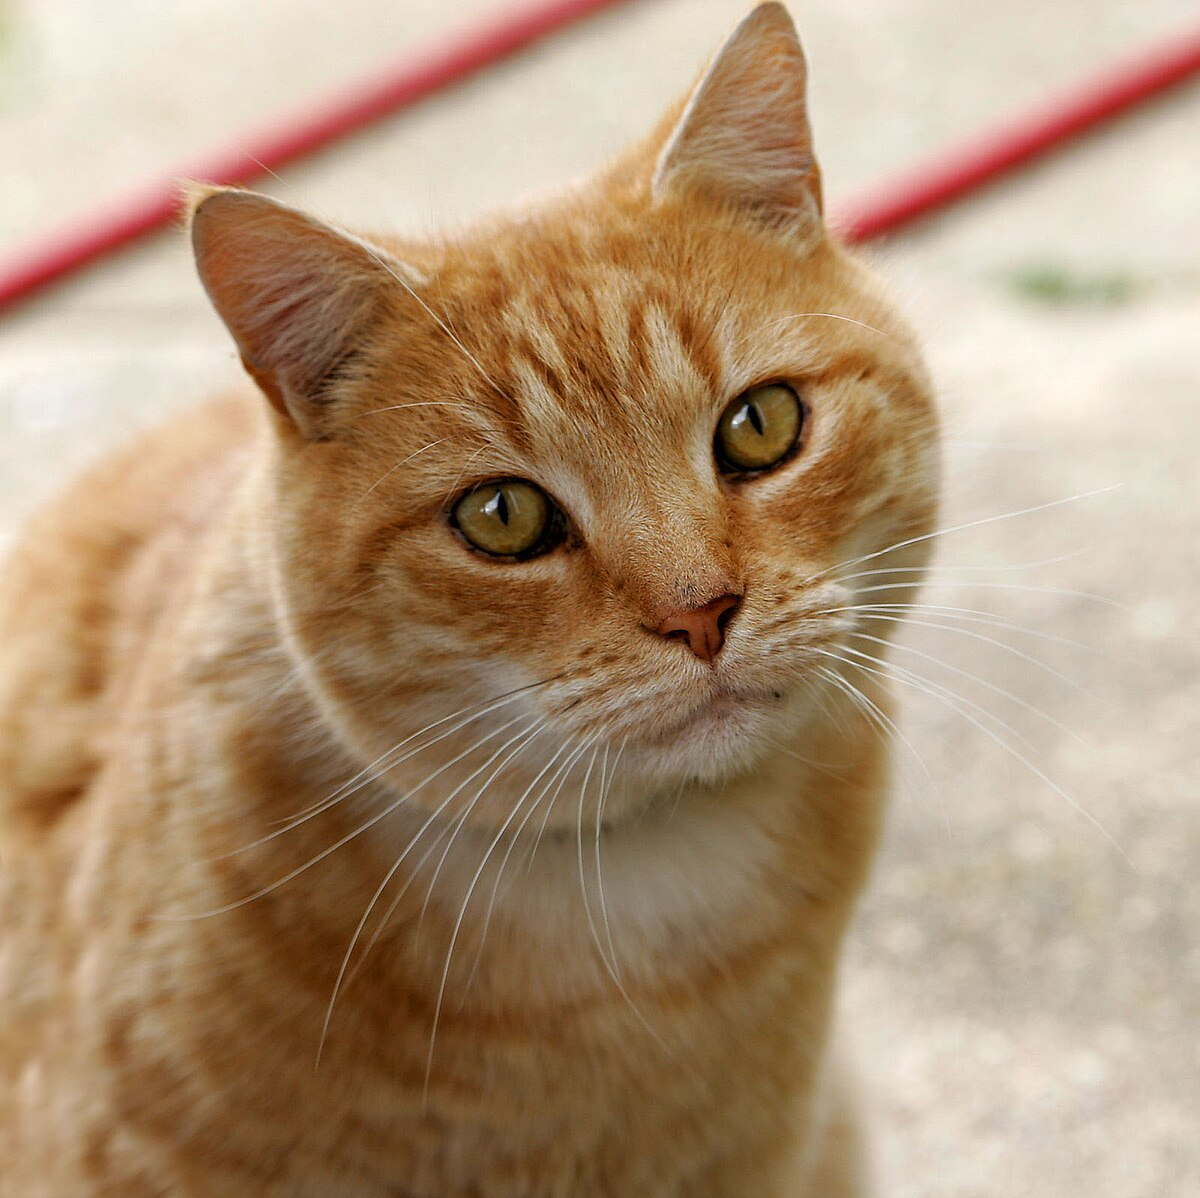

🔍 Top 3 text matches for cat.jpg:
  1. "A cute ginger cat sitting and looking at the camera" (score: 0.432)
  2. "A dog playing fetch in a park" (score: 0.236)
  3. "A plate of sushi with wasabi and ginger" (score: 0.218)


In [11]:
# Expanded text corpus for richer matching
text_corpus = [
    "A person flying with a jetpack through the sky",
    "Freshly baked scones with jam and cream on a plate",
    "A cute ginger cat sitting and looking at the camera",
    "Trees and nature sounds in a peaceful forest",
    "A rocket launching into space",
    "A sketch of a jetpack backpack",
    "A dog playing fetch in a park",
    "A plate of sushi with wasabi and ginger",
    "A futuristic cityscape at night with neon lights",
    "A person riding a bicycle on a mountain trail",
    "A cozy fireplace with a cup of hot chocolate",
]

print("Embedding expanded text corpus (10 entries)...")
corpus_embeddings = np.array([embed_text(t) for t in text_corpus])

# For each image, find the top-3 most similar texts
image_corpus_sim = cosine_similarity(image_embeddings, corpus_embeddings)

for i, img in enumerate(image_labels):
    print(f"\n{'='*60}")
    display(IPImage(filename=image_files[i], width=250))
    print(f"\U0001f50d Top 3 text matches for {img}:")
    top_indices = np.argsort(image_corpus_sim[i])[::-1][:3]
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}. \"{text_corpus[idx]}\" (score: {image_corpus_sim[i, idx]:.3f})")

In [12]:
!wget -O handwriting_form.pdf https://storage.googleapis.com/generativeai-downloads/data/pdf_structured_outputs/handwriting_form.pdf  -q

In [13]:
with open('handwriting_form.pdf', 'rb') as f:
    pdf_bytes = f.read()

result = client.models.embed_content(
    model='gemini-embedding-2-preview',
    contents=[
        types.Part.from_bytes(
            data=pdf_bytes,
            mime_type='application/pdf',
        ),
    ]
)

print(result.embeddings)

[ContentEmbedding(
  values=[
    -0.003082171,
    -0.01203966,
    -0.0055089607,
    -0.027500032,
    0.007748906,
    <... 3067 more items ...>,
  ]
)]


In [18]:
#aggreagation
with open('jetpack.png', 'rb') as f:
    image_bytes = f.read()

result = client.models.embed_content(
    model='gemini-embedding-2-preview',
    contents=[
        types.Content(
            parts=[
                types.Part(text="An image of a jetpack"),
                types.Part.from_bytes(
                    data=image_bytes,
                    mime_type='image/png',
                )
            ]
        )
    ]
)

# This produces one embedding
for embedding in result.embeddings:
    print(len(embedding.values))
    print(embedding.values)

3072
[-0.033919916, 0.015483184, -0.0036192224, 0.007073024, 0.009602212, 0.003022928, -0.018546147, -0.0016627455, 0.0015988419, -0.039696403, -0.031238241, -0.009223876, -0.008227062, -0.015388866, 0.00885734, -0.0008911571, 0.026177177, -0.0090352055, -0.001178035, -0.016270531, 0.0006055537, -0.016158812, -0.00434208, 0.012923678, 0.0018959797, -0.003748785, -0.004307565, -0.013378615, 0.020149902, 0.07499765, -0.0154990945, 0.0002734665, 0.001955334, -0.005983663, -0.003835433, 0.00029300604, 0.014412917, 0.018657219, -0.0065289577, -0.010347964, -0.0006696447, 0.010446259, 0.005714131, 0.006538843, -0.018843787, 0.03808481, -1.718031e-05, -0.0015707385, 0.00020589809, 0.0026783182, 0.0062763537, 0.015751831, 0.014902925, -0.002504783, 0.015887419, 0.015490579, -0.01978142, -0.00643889, 0.027535938, -0.010763305, 0.0063087675, 0.017215706, -0.004766326, 0.012711691, -0.0094138, -0.0033116217, 0.0037430492, 0.007947636, 0.006026079, -0.019435335, -0.024137855, 0.0002095561, -0.0201

In [26]:
import numpy as np

result = client.models.embed_content(
    model='gemini-embedding-2-preview',
    contents=[
        "An image of a jetpack",
        types.Part.from_bytes(
            data=image_bytes,
            mime_type='image/png',
        ),
    ]
)

# İki ayrı embedding gelir
for embedding in result.embeddings:
    print(len(embedding.values))

# Ortalama almak için → numpy array'e çevir
embeddings_array = np.array([e.values for e in result.embeddings])
mean_embedding = embeddings_array.mean(axis=0)

print(mean_embedding)
print(mean_embedding.shape)  # (3072,) olmalı

3072
3072
[-0.04094347  0.00691305  0.00408939 ...  0.00755954 -0.00575175
  0.00671855]
(3072,)


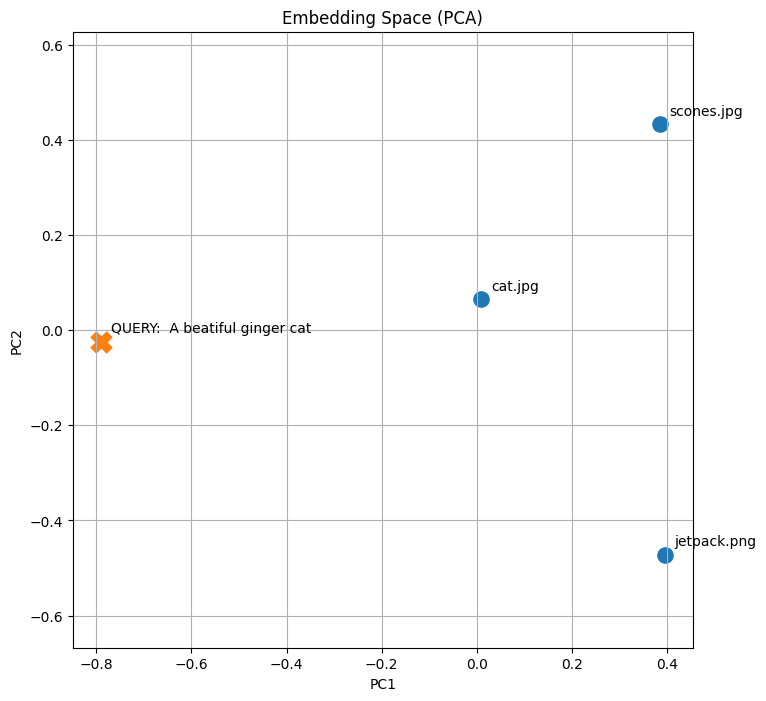

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Get embeddings from Chroma


embeddings = image_embeddings
labels = image_labels

# Embed query
query = " A beatiful ginger cat"
query_embedding = np.array(embed_text(query))

# Combine embeddings
all_embeddings = np.vstack([embeddings, query_embedding])
all_labels = labels + [f"QUERY: {query}"]

# PCA → 2D
pca = PCA(n_components=2)
points = pca.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(8,8))

# Files
plt.scatter(points[:-1,0], points[:-1,1], s=120)

# Query
plt.scatter(points[-1,0], points[-1,1], s=220, marker="X")

# Labels
for i, label in enumerate(all_labels):
    plt.text(points[i,0]+0.02, points[i,1]+0.02, label)

plt.title("Embedding Space (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# IMPORTANT: same scale for both axes
plt.axis("equal")

plt.grid(True)
plt.show()